# Missing values 
## 1. Missing Completely at Random, MCAR: 
No specific reason behind the missing data, they are just missing, simply no reason needed or specified.
## 2. Missing at Random, MAR:
The missing data is systematically related to the observed data but not the other missing data. Ex: People don't want to disclose their salaries and incomes.
## 3. Missing data not at random, MNAR:
The missingness is not random and is dependent on unobserved or unmeasured factors that are associated with the missing values. Ex: Employee who are not satisfied with ther jobs are more likely to refuse to give out their income. Hence the missing data is not at random.


## Examples

In [1]:
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
## Delete the rows or data points to handle missing values

df.shape

(891, 15)

In [6]:
df.dropna().shape

(182, 15)

In [7]:
## Column wise deletion
df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


## Imputation Missing Value

## 1- Mean value Imputation

<Axes: xlabel='age', ylabel='Count'>

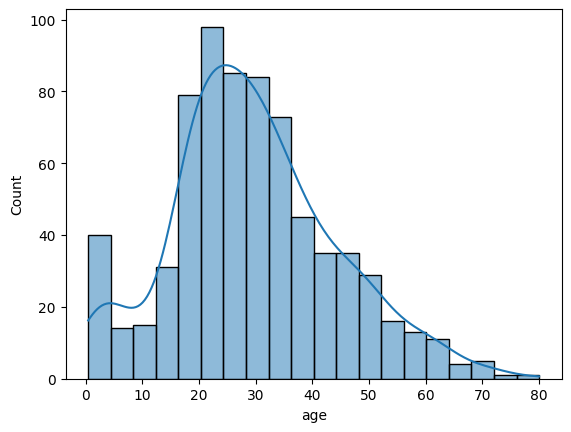

In [8]:
sns.histplot(df['age'],kde=True)

In [9]:
df['Age_mean']=df['age'].fillna(df['age'].mean())

In [10]:
df[['Age_mean','age']]

,Age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [11]:
## Mean imputation works well when we have normally distributted data

## 2. Median Value Imputation- if we have outliers in the dataset

In [12]:
df['median_age']= df['age'].fillna(df['age'].median())

In [13]:
df[['median_age','Age_mean','age']]

,median_age,Age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


## 3. Mode Imputation Technique

In [14]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_mean,median_age
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [15]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [16]:
mode= df[df['embarked'].notna()]['embarked'].mode()[0]

In [17]:
df['embarked_mode']=df['embarked'].fillna(mode)

In [18]:
df[['embarked_mode','embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [19]:
df[['embarked_mode','embarked']].iloc[61]

embarked_mode      S
embarked         NaN
Name: 61, dtype: object

In [20]:
## Random Sampling Technique: Using random 
import pandas as pd

In [21]:
df['embarked_random_sampling']= df['embarked'].apply(lambda x: x if pd.notnull(x) else df['embarked'].sample(1).values[0])

In [22]:
df[['embarked_random_sampling','embarked']].iloc[61]

embarked_random_sampling      Q
embarked                    NaN
Name: 61, dtype: object

<Axes: xlabel='embarked', ylabel='Count'>

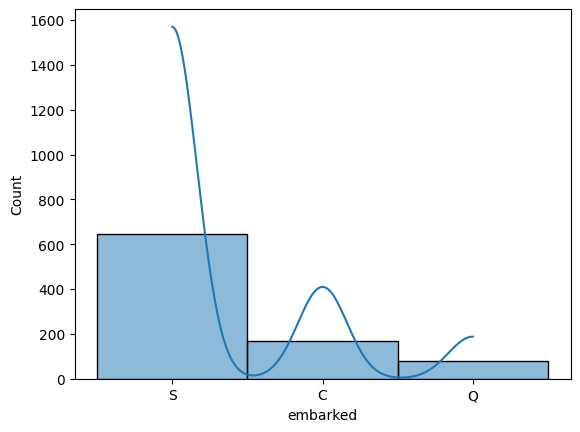

In [23]:
sns.histplot(df['embarked'],kde=True)

<Axes: xlabel='embarked_random_sampling', ylabel='Count'>

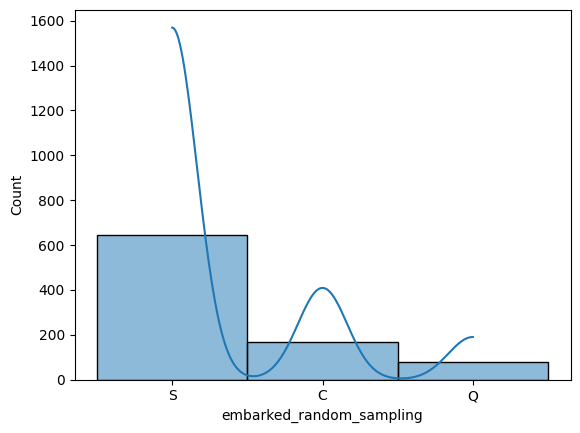

In [24]:
sns.histplot(df['embarked_random_sampling'],kde=True)

<Axes: ylabel='Density'>

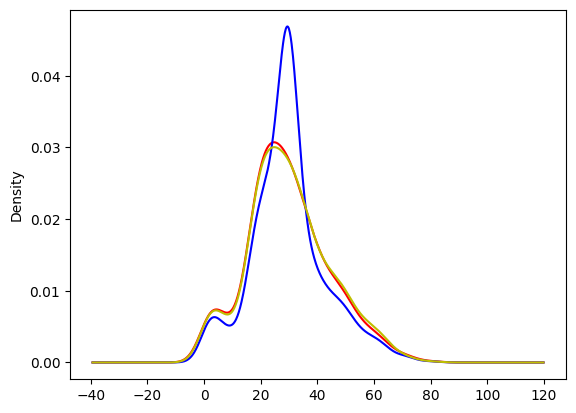

In [25]:
df['Age_mean']= df['age'].fillna(df['age'].mean())
df['Age_median']= df['age'].fillna(df['age'].median())
df['Age_random']= df['age'].apply(lambda x: x if pd.notnull(x) else df['age'].sample(1).values[0])
import matplotlib.pyplot as plt

plt.figure()
df['age'].plot(kind='kde',color='r')
df['Age_mean'].plot(kind='kde',color='b')
df['Age_random'].plot(kind='kde',color='y')

# Handling Imbalanced Dataset
1. Up Sampling
2. Down Sampling


In [26]:
import numpy as np
import pandas as pd

np.random.seed(123)

n_samples = 1000
class_0_ratio = 0.9
n_class_0= int(n_samples*class_0_ratio)
n_class_1 = n_samples - n_class_0

In [27]:
n_class_0,n_class_1

(900, 100)

In [28]:
## Create my df
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

In [29]:
df = pd.concat([class_0,class_1]).reset_index(drop=True)

In [30]:
df.target.value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [31]:
## upsampling
df_minor = df[df['target']==1]
df_major = df[df['target']==0]

In [32]:
from sklearn.utils import resample
df_minor_upsample = resample(df_minor, replace=True, 
                             n_samples=len(df_major), 
                             random_state = 42)

In [33]:
df_minor_upsample.shape

(900, 3)

In [34]:
df_minor_upsample.head()

,feature_1,feature_2,target
951,-0.874146,-0.156083,1
992,0.196570,-0.602575,1
914,-0.067830,0.998053,1
971,0.272825,1.034197,1
960,0.870056,-0.449515,1


In [35]:
df_upsampled = pd.concat([df_major,df_minor_upsample])

In [36]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [37]:
## Downsampling

df_major_downsample = resample(df_major, 
                               replace=False,
                               n_samples= len(df_minor),
                              random_state=42)

In [38]:
df_major_downsample.shape

(100, 3)

In [39]:
df_downsampled = pd.concat([df_major_downsample,df_minor])

In [40]:
df_downsampled.target.value_counts()

target
0    100
1    100
Name: count, dtype: int64

# SMOTE (Synthetic Minority Oversampling Technique)
SMOTE(Synthetic Minority OverSampling Technique) is a technique used in machine learning to address imbalanced datasets where the 
minority class has significantly fewer instances tha the majority class. SMOTE involves generating synthetic instances of the minority
class by interpolating between existing instances.

In [41]:
from sklearn.datasets import make_classification

In [42]:
x,y = make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.9],random_state=12)

In [43]:
import pandas as pd
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1,df2],axis = 1)

In [44]:
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [45]:
final_df.target.value_counts()

target
0    900
1    100
Name: count, dtype: int64

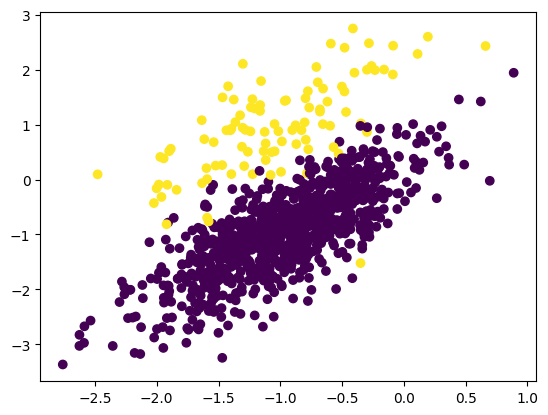

In [46]:
import matplotlib.pyplot as plt
plt.scatter(final_df.f1,final_df.f2,c=final_df.target)

In [47]:
!pip install imblearn

In [48]:
from imblearn.over_sampling import SMOTE

In [49]:
oversample= SMOTE()
x,y = oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [50]:
x.shape

(1800, 2)

In [51]:
y.shape

(1800,)

In [52]:
len(y[y==0])

900

In [53]:
df1= pd.DataFrame(x, columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
df_oversample = pd.concat([df1,df2],axis=1)

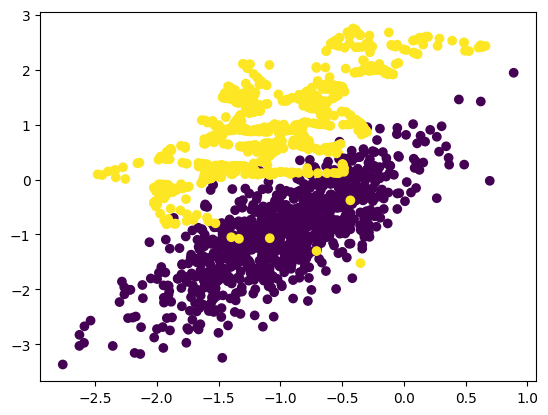

In [54]:
plt.scatter(df_oversample['f1'],df_oversample['f2'],c=df_oversample['target'])

# 5 Number Summary and Box Plot

In [55]:
import numpy as np

In [56]:
lst_marks= np.random.randint(0,100,size=20)
min,q1,median,q3,max= np.quantile(lst_marks,[0,0.25,0.5,0.75,1])

In [57]:
q1, median

(np.float64(38.75), np.float64(49.5))

In [58]:
lst_marks

array([41, 50, 48, 52, 60, 89, 56, 75, 41, 22, 32, 38, 57, 37, 17, 88, 96,
       93, 49, 39], dtype=int32)

In [59]:
Iqr = q3-q1
print(Iqr)

25.0


In [60]:
lower_fence= q1-1.5*Iqr
higher_fence = q3+1.5*Iqr
print(lower_fence,higher_fence)

1.25 101.25


In [61]:
q1

np.float64(38.75)

In [62]:
import seaborn as sns

{'whiskers': [<matplotlib.lines.Line2D at 0x1af3d1a0f50>,
 'caps': [<matplotlib.lines.Line2D at 0x1af3d1a11d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1af3d1a0e10>],
 'medians': [<matplotlib.lines.Line2D at 0x1af3d1a1450>],
 'fliers': [<matplotlib.lines.Line2D at 0x1af3d1a1590>],
 'means': []}

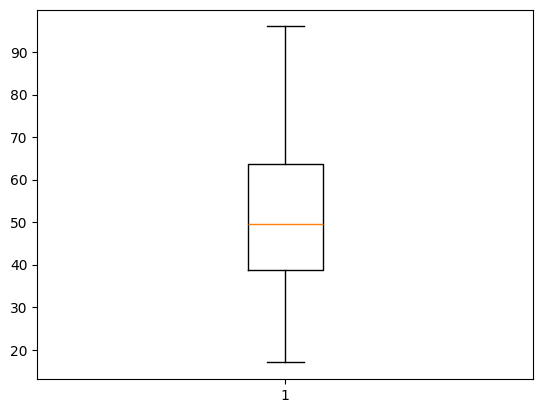

In [63]:
plt.boxplot(lst_marks)

<Axes: >

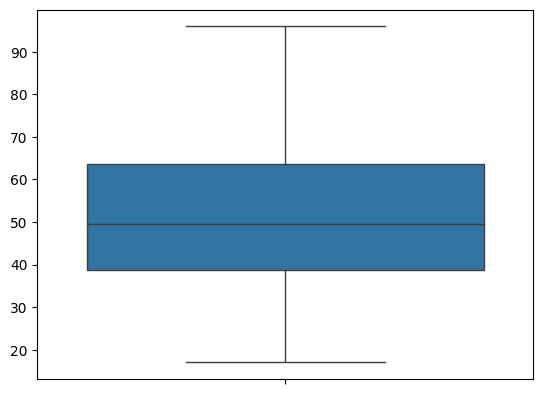

In [64]:
sns.boxplot(lst_marks)

In [65]:
lst_marks = np.append(lst_marks,[1200,100,-34])

<Axes: >

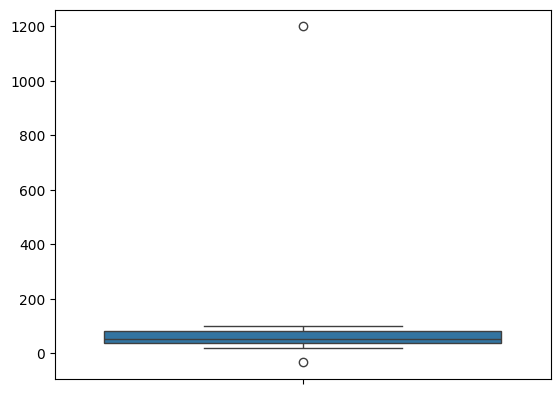

In [66]:
sns.boxplot(lst_marks)

# Data Encoding 
1. Nominal/OHE Encoding
2. Label and Ordinal Encoding
3. Target Guided Ordinal Encoding

## Nominal/OHE Encoding 
One Hot encoding also known as nominal encoding, is a technique used to represent categorical data as numerical data, 
which is more suitable for machine learning algorithms. In this technique, each category is represented as a binary vector 
where each bit corresponds to a unique category. For example, if we have a categorical variable 'color' with three possible 
values (red, blue, green) we can represent it in one hot encoding as:

    1. Red: [1,0,0]
    2. Green: [0,1,0]
    3. Blue: [0,0,1]
# Disadvantages 
    1. It creates really long vectors when there are numerous categories(features). Ex: [0,0,0,0,0,0,0,0,0,1,0,0,..] 
    2. It leads to sparse matrix => Overfitting

In [67]:
from sklearn.preprocessing import OneHotEncoder

In [68]:
## Create a simple df
df = pd.DataFrame({
    'color': ['red','blue','green','green','red','blue']
})

In [69]:
df

,color
0,red
1,blue
2,green
3,green
4,red
5,blue


In [70]:
## Create an instance of OHE
encoder = OneHotEncoder()

In [71]:
## Perform fit and transform
encoded = encoder.fit_transform(df[['color']]).toarray()

In [72]:
encoder_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())

In [73]:
encoder_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [74]:
encoder.transform([['blue']]).toarray()

C:\Users\palla\miniconda3\envs\MLOps\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [75]:
pd.concat([df,encoder_df],axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


In [76]:
df = sns.load_dataset('tips')

In [77]:
encoded_sex = encoder.fit_transform(df[['sex']]).toarray()

In [78]:
encoded_sex_df = pd.DataFrame(encoded_sex, columns=encoder.get_feature_names_out())

In [79]:
encoded_sex_df

,sex_Female,sex_Male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
239,0.0,1.0
240,1.0,0.0
241,0.0,1.0
242,0.0,1.0


In [80]:
df = pd.concat([df,encoded_sex_df],axis=1)

In [81]:
df

,total_bill,tip,sex,smoker,day,time,size,sex_Female,sex_Male
0,16.99,1.01,Female,No,Sun,Dinner,2,1.0,0.0
1,10.34,1.66,Male,No,Sun,Dinner,3,0.0,1.0
2,21.01,3.50,Male,No,Sun,Dinner,3,0.0,1.0
3,23.68,3.31,Male,No,Sun,Dinner,2,0.0,1.0
4,24.59,3.61,Female,No,Sun,Dinner,4,1.0,0.0
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.0,1.0
240,27.18,2.00,Female,Yes,Sat,Dinner,2,1.0,0.0
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.0,1.0
242,17.82,1.75,Male,No,Sat,Dinner,2,0.0,1.0


In [82]:
encoded_time = encoder.fit_transform(df[['time']]).toarray()

In [83]:
encoded_time = pd.DataFrame(encoded_time,columns=encoder.get_feature_names_out())

In [84]:
df = df.drop('time',axis = 1)

In [85]:
df = pd.concat([df,encoded_time],axis=1)

In [86]:
df

,total_bill,tip,sex,smoker,day,size,sex_Female,sex_Male,time_Dinner,time_Lunch
0,16.99,1.01,Female,No,Sun,2,1.0,0.0,1.0,0.0
1,10.34,1.66,Male,No,Sun,3,0.0,1.0,1.0,0.0
2,21.01,3.50,Male,No,Sun,3,0.0,1.0,1.0,0.0
3,23.68,3.31,Male,No,Sun,2,0.0,1.0,1.0,0.0
4,24.59,3.61,Female,No,Sun,4,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,3,0.0,1.0,1.0,0.0
240,27.18,2.00,Female,Yes,Sat,2,1.0,0.0,1.0,0.0
241,22.67,2.00,Male,Yes,Sat,2,0.0,1.0,1.0,0.0
242,17.82,1.75,Male,No,Sat,2,0.0,1.0,1.0,0.0


In [88]:
smoker = encoder.fit_transform(df[['smoker']]).toarray()

In [89]:
smoker = pd.DataFrame(smoker,columns=encoder.get_feature_names_out())

In [90]:
df = df.drop('smoker',axis=1)

In [91]:
df = pd.concat([df,smoker],axis=1)

In [92]:
df

,total_bill,tip,sex,day,size,sex_Female,sex_Male,time_Dinner,time_Lunch,smoker_No,smoker_Yes
0,16.99,1.01,Female,Sun,2,1.0,0.0,1.0,0.0,1.0,0.0
1,10.34,1.66,Male,Sun,3,0.0,1.0,1.0,0.0,1.0,0.0
2,21.01,3.50,Male,Sun,3,0.0,1.0,1.0,0.0,1.0,0.0
3,23.68,3.31,Male,Sun,2,0.0,1.0,1.0,0.0,1.0,0.0
4,24.59,3.61,Female,Sun,4,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,Sat,3,0.0,1.0,1.0,0.0,1.0,0.0
240,27.18,2.00,Female,Sat,2,1.0,0.0,1.0,0.0,0.0,1.0
241,22.67,2.00,Male,Sat,2,0.0,1.0,1.0,0.0,0.0,1.0
242,17.82,1.75,Male,Sat,2,0.0,1.0,1.0,0.0,1.0,0.0


In [93]:
df = df.drop('sex',axis=1)

In [94]:
day = encoder.fit_transform(df[['day']]).toarray()

In [96]:
day = pd.DataFrame(day,columns=encoder.get_feature_names_out())

In [97]:
df = pd.concat([df,day],axis =1)

In [98]:
df

,total_bill,tip,day,size,sex_Female,sex_Male,time_Dinner,time_Lunch,smoker_No,smoker_Yes,day_Fri,day_Sat,day_Sun,day_Thur
0,16.99,1.01,Sun,2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,10.34,1.66,Sun,3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,21.01,3.50,Sun,3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,23.68,3.31,Sun,2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,24.59,3.61,Sun,4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Sat,3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
240,27.18,2.00,Sat,2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
241,22.67,2.00,Sat,2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
242,17.82,1.75,Sat,2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [99]:
df = df.drop('day',axis=1)

In [100]:
df

,total_bill,tip,size,sex_Female,sex_Male,time_Dinner,time_Lunch,smoker_No,smoker_Yes,day_Fri,day_Sat,day_Sun,day_Thur
0,16.99,1.01,2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,10.34,1.66,3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,21.01,3.50,3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,23.68,3.31,2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,24.59,3.61,4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
240,27.18,2.00,2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
241,22.67,2.00,2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
242,17.82,1.75,2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


## Label Encoding

Label encoding and ordinal encoding are two techniques used to encode categorical data as numerical data.

Label encoding involves assigning a unique numerical label to each category in the variable. The labels are usually assigned in alphabetical order or based on the frequency of the categories. For example, if we have a categorical variable 'color' with three values:

1. Red: 1
2. Green: 2
3. Blue: 3

In [103]:
df = pd.DataFrame(['red','blue','green','green','red'])

In [104]:
df.head()

,0
0,red
1,blue
2,green
3,green
4,red


In [108]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder = LabelEncoder()

In [109]:
lbl_encoder.fit_transform(df)

C:\Users\palla\miniconda3\envs\MLOps\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 0, 1, 1, 2])

In [112]:
lbl_encoder.transform(['red'])

array([2])

## Ordinal Encoding 
It is used to encoder categorical data that have an intrinsic order or ranking. In this technique, each category is assigned a numerical value based on its position in that order. For example:

1. High School: 1
2. College: 2
3. Graduate: 3
4. Post-Graduate: 4

This is important to show that there is a heirarchy involved here.

In [113]:
from sklearn.preprocessing import OrdinalEncoder


In [114]:
df = pd.DataFrame({
    'size' : ['small', 'medium', 'large', 'medium', 'small', 'large']
})

In [115]:
df

,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [120]:
ord_encoder = OrdinalEncoder(categories=[['small','medium','large']])

In [121]:
ord_encoder.fit_transform(df[['size']])

array([[0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.]])

In [124]:
ord_encoder.transform([['small']])

C:\Users\palla\miniconda3\envs\MLOps\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[0.]])

## Target Guided Ordinal Encoding
It is a technique used to encode categorical variables based on their relationship with the target variable. This is encoding technique is useful when we have a categorical variable with a large no. of unique categories, and we want to use this variable as a feature in our machine learning model. 

In Target Guided Ordinal Encoding, we replace each category in the categorical variable with a numerical value based on the mean or median of the target variable for that category. This creates a monotonic relationship between the categorical value and the target variable, which can improve the predictive power of our model. 

In [125]:
df = pd.DataFrame({
    'city':['New York','London','Paris','Tokyo','New York', "Paris"],
    'price':[200,150,300,250,180,320]
})

In [126]:
df

,city,price
0,New York,200
1,London,150
2,Paris,300
3,Tokyo,250
4,New York,180
5,Paris,320


In [130]:
mean_price = df.groupby('city')['price'].mean().to_dict()

In [131]:
mean_price

{'London': 150.0, 'New York': 190.0, 'Paris': 310.0, 'Tokyo': 250.0}

In [132]:
df['city_encoded']=df['city'].map(mean_price)

In [133]:
df

,city,price,city_encoded
0,New York,200,190.0
1,London,150,150.0
2,Paris,300,310.0
3,Tokyo,250,250.0
4,New York,180,190.0
5,Paris,320,310.0


In [135]:
df[['price','city_encoded']]

,price,city_encoded
0,200,190.0
1,150,150.0
2,300,310.0
3,250,250.0
4,180,190.0
5,320,310.0


In [136]:
df = sns.load_dataset('tips')

In [137]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [140]:
mean_bill = df.groupby('time')['total_bill'].mean().to_dict()

C:\Users\palla\AppData\Local\Temp\ipykernel_8668\3722957593.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_bill = df.groupby('time')['total_bill'].mean().to_dict()


In [141]:
mean_bill

{'Lunch': 17.168676470588235, 'Dinner': 20.79715909090909}

In [142]:
df['time_encoded']= df['time'].map(mean_bill)

In [143]:
df

,total_bill,tip,sex,smoker,day,time,size,time_encoded
0,16.99,1.01,Female,No,Sun,Dinner,2,20.797159
1,10.34,1.66,Male,No,Sun,Dinner,3,20.797159
2,21.01,3.50,Male,No,Sun,Dinner,3,20.797159
3,23.68,3.31,Male,No,Sun,Dinner,2,20.797159
4,24.59,3.61,Female,No,Sun,Dinner,4,20.797159
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.797159
240,27.18,2.00,Female,Yes,Sat,Dinner,2,20.797159
241,22.67,2.00,Male,Yes,Sat,Dinner,2,20.797159
242,17.82,1.75,Male,No,Sat,Dinner,2,20.797159
